# The Fortune 500 pop — does making the list pay? 🏆
### Being added to a famous list *should* pop the stock… shouldn't it? — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Attention_effect%3F: Not supported](https://img.shields.io/badge/Attention_effect%3F-Not_supported-8b949e?style=flat-square)

Here's a tidy-sounding trade. There's a real, textbook effect where a stock **added to the S&P 500** jumps — index funds are *forced* to buy it, so the price pops. So surely a company's **debut on the Fortune 500** — Tesla in 2017, Airbnb and Coinbase in 2022, Robinhood in 2024 — gets the same prestige bump, and a company that **falls off** takes a hit? Buy the newcomers on reveal day, maybe short the drop-offs.

It borrows its plausibility from something real. This notebook asks whether the borrow is legitimate — by building a transparent table of **26 real Fortune-500 debuts and exits** and measuring what actually happened to each around the June reveal.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **The catch, up front.** The S&P 500 is an *investable index* — funds must track it, so an addition is a genuine buying shock. The Fortune 500 is a **magazine ranking by last year's revenue**: no fund tracks it, nobody's forced to buy, and the revenue that decides the ranking was public months ago. Strip out the forced buying and the news, and all that's left is *prestige*. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fortune_500_inclusion import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
PANEL = st.car_panel(PRICES, EVENTS) if HAVE_REAL else None
print("real add/drop-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'fingerprint': '9b280bbd9147', 'as_of': '2026-07-12', 'n_table': 26, 'n_delisted': 3, 'n_added': 14, 'n_dropped': 12, 'added': (0.06, 50, 0.04), 'dropped': (0.12, 50, 0.06), 'allb': (0.09, 50, 0.07), 'diff_pp': -0.06, 'diff_t': -0.02, 'added_placebo_p': 0.966, 'day0': (-0.47, -0.56, 0.556, -0.12), 'tradable': [('[+1,+3]', 0.88, 0.6, -0.22, 0.78), ('[+1,+5]', 2.23, 1.39, 0.2, 2.13)], 'robust': [('[0,0]', -0.47, -0.56, -0.25, -0.21, -0.12), ('[0,+2]', 0.06, 0.04, 0.12, -0.06, -0.02), ('[-1,+1]', -2.14, -1.34, -0.44, -1.7, -0.75), ('[0,+4]', 1.62, 1.15, 0.89, 0.73, 0.27)], 'syn': [(0, 0.49, 0.48, 1.39, 0.9), (500, 5.49, 5.4, 6.39, 4.1)]}


real add/drop-tape cache present: True | events priced: 26


## The answer first

| Question | Answer |
|---|---|
| Does joining the Fortune 500 pop the stock? | **No.** Across 14 debuts the reveal-window abnormal return averages **+0.06%** — and it's a perfect coin-flip (**50%** of the time positive). |
| Does falling off the list hurt it? | **No.** The 12 drop-offs average **+0.12%** — if anything *up*, and also a 50/50 coin-flip. |
| Is there any gap between joining and dropping? | **None.** Added minus dropped is **-0.06 percentage points** — statistically zero. |
| Then why does 'the list moves stocks' sound true? | It's borrowed from the **S&P 500**, where index funds are *forced* to buy. The Fortune 500 forces no one to do anything. |

> The prestige pop is a myth: there's no bump for joining, no penalty for leaving, and no gap between them. A random press release looks this 'special' **97%** of the time.

## 1 · The claim

> *"Making the Fortune 500 is a milestone — it brings analyst coverage, press, prestige, and a wave of investor attention. The stock pops on the reveal. And a company that drops off loses all that, so it sags. Buy the debutants, fade the drop-offs."*

It's not a crazy claim — it rhymes with something **genuinely real**. The classic index-inclusion studies (Shleifer 1986; Harris & Gurel 1986) found that stocks **added to the S&P 500** earn a real abnormal return around the change. The believers simply extend that to the Fortune 500. We'll test whether the extension holds — on a real, representative table of debuts and exits, both legs.

## 2 · So what?

If it were real, it'd be a free calendar: every June, Fortune hands you a list of stocks to buy (the newcomers) and stocks to short (the drop-offs), on a *pre-announced date*. But the whole reason the S&P-500 version works is a **mechanism**: index funds *must* buy the addition, a forced demand shock. The Fortune 500 has **no such mechanism** — no fund tracks it — and it carries **no new information**, because the ranking is built from revenue that was reported months earlier. So this is really a clean test of a deeper question: does **prestige and attention, by themselves**, move a stock price? If the answer is no, the 'trade' was never a trade.

## 3 · How would we even know?

We build a **transparent table of 26 real Fortune-500 events** — **14 debuts** (Tesla, Netflix, Uber, Airbnb, Coinbase, Moderna, DoorDash, CrowdStrike, Robinhood…) and **12 exits** (Mattel, GameStop, Xerox, Bed Bath & Beyond, Gap, Hasbro…), each pinned to its June reveal date. For each one:

1. **Line it up against the market.** Fit the stock to the S&P (SPY) on a clean stretch *before* the reveal, so we know how it normally moves.
2. **Measure the abnormal return.** The bit of the reveal-window move that *isn't* just the market — the actual 'prestige pop', if there is one.
3. **Stress the luck.** Draw the same number of *random* dates on the same stocks, thousands of times, and ask how often chance produces a pop this big. With ~a dozen events per side, that's the honest test.

And we say it loudly: the worst drop-offs (J.C. Penney, Bed Bath & Beyond) went **bankrupt** and vanished from the data — so the exits we *can* price are the *survivors*, biased **against** a drop-off penalty. Even so, the penalty isn't there.

## 4 · The teardown — let's actually look

**First, every event.** The reveal-window abnormal (market-adjusted) return for all 26 debuts and exits — greens are joiners, reds are drop-offs.

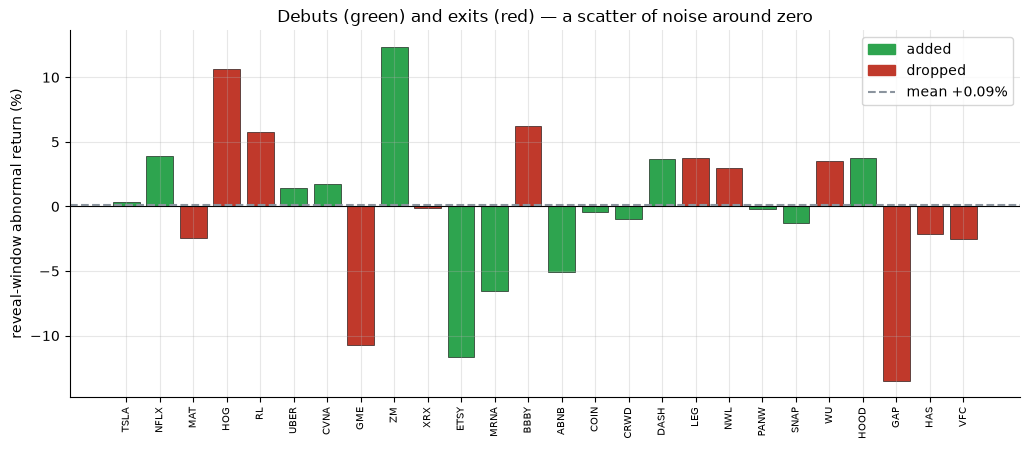

overall mean abnormal return +0.09%  —  positive events: 50%


In [2]:
if HAVE_REAL:
    p = PANEL.sort_values('list_date')
    vals = p['car'].values*100; labs = p['ticker'].values; added = p['added'].values
else:
    rng=np.random.default_rng(751); vals=rng.normal(0.1,6,R['n_table'])
    labs=[f'E{i}' for i in range(R['n_table'])]; added=np.array([True]*R['n_added']+[False]*R['n_dropped'])
colors=[GREEN if a else RED for a in added]
fig, ax = plt.subplots(figsize=(10.4, 4.6))
ax.bar(range(len(vals)), vals, color=colors, edgecolor='k', lw=.4)
ax.axhline(0, c='k', lw=.8)
ax.axhline(np.mean(vals), c=GREY, ls='--', label=f'overall mean {np.mean(vals):+.2f}%')
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=90, fontsize=7)
ax.set_ylabel('reveal-window abnormal return (%)')
ax.set_title('Debuts (green) and exits (red) — a scatter of noise around zero')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GREEN,label='added'),Patch(color=RED,label='dropped'),
                   plt.Line2D([0],[0],c=GREY,ls='--',label=f'mean {np.mean(vals):+.2f}%')])
plt.tight_layout(); plt.show()
print(f'overall mean abnormal return {np.mean(vals):+.2f}%  —  positive events: {(vals>0).mean()*100:.0f}%')

There's the tell. If joining the list popped stocks, the greens would cluster **above** zero and the reds **below**. Instead it's a hedge — some up, some down, both colours on both sides — averaging essentially **zero**. HOG (+11%) and ZM (+12%) are up; ETSY (−12%) and GAP (−13%) are down; none of it lines up with joining vs leaving.

**The two buckets as averages.** Mean abnormal return for the debuts vs the exits, with the win-rate (how often each is positive). A coin is 50%.

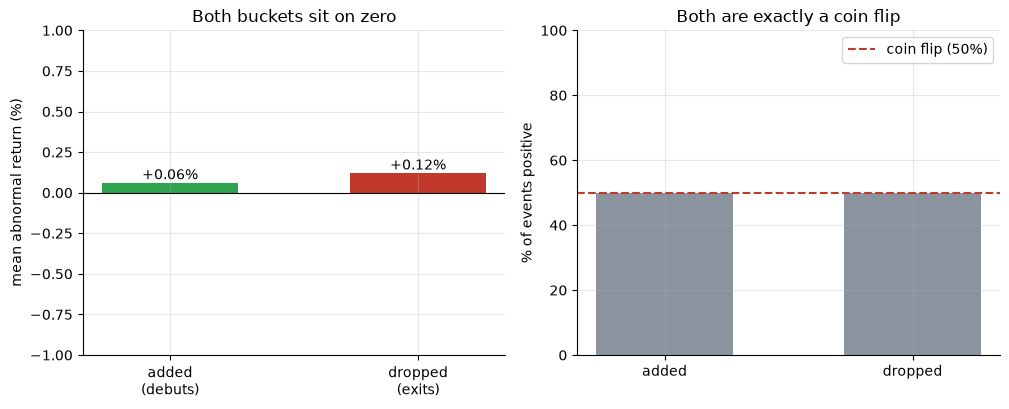

added +0.06% (win 50%)   dropped +0.12% (win 50%)


In [3]:
if HAVE_REAL:
    s = st.summarize(PANEL)
    am, aw = s['added']['mean_pct'], s['added']['win']*100
    dm, dw = s['dropped']['mean_pct'], s['dropped']['win']*100
else:
    am, aw, dm, dw = R['added'][0], R['added'][1], R['dropped'][0], R['dropped'][1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(['added\n(debuts)', 'dropped\n(exits)'], [am, dm], color=[GREEN, RED], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (%)')
a1.set_title('Both buckets sit on zero'); a1.set_ylim(-1, 1)
for i,v in enumerate([am,dm]): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.bar(['added','dropped'], [aw, dw], color=GREY, width=.55)
a2.axhline(50, c=RED, ls='--', label='coin flip (50%)')
a2.set_ylim(0,100); a2.set_ylabel('% of events positive'); a2.set_title('Both are exactly a coin flip')
a2.legend(); plt.tight_layout(); plt.show()
print(f'added {am:+.2f}% (win {aw:.0f}%)   dropped {dm:+.2f}% (win {dw:.0f}%)')

The debuts pop **+0.06%** and the exits **+0.12%** — both positive only **50%** of the time, a literal coin flip. There's no bump for joining, no penalty for leaving, and the two are on top of each other.

**Could a handful of random dates look this good?** The honest small-sample test: draw **14** *random* dates on the same stocks, over and over, and see where the real debut pop lands against pure luck.

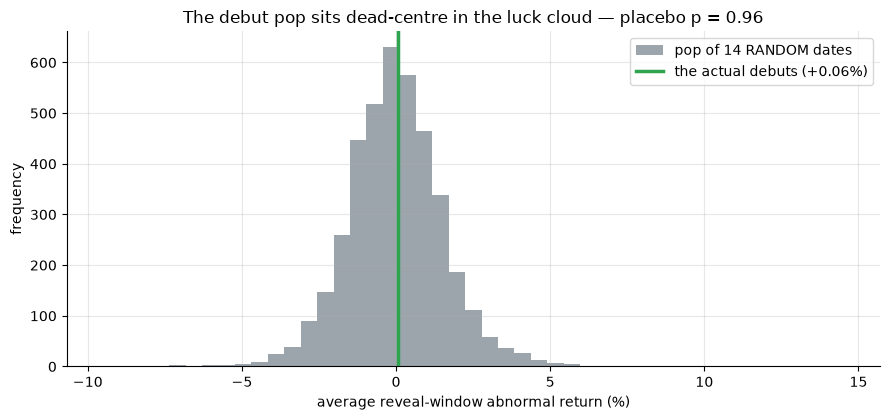

a random 14-date draw matches the debut pop 96% of the time — as ordinary as it gets


In [4]:
if HAVE_REAL:
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=int(PANEL['added'].sum()), n_draws=4000)
    obs = PANEL.loc[PANEL['added'],'car'].mean()*100; draws = null*100
    pval = st.placebo_pvalue(obs/100, null)
else:
    obs=R['added'][0]; pval=R['added_placebo_p']; rng=np.random.default_rng(751); draws=rng.normal(0,1.6,4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label=f'pop of {R["n_added"]} RANDOM dates')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the actual debuts ({obs:+.2f}%)')
ax.set_xlabel('average reveal-window abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The debut pop sits dead-centre in the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random {R["n_added"]}-date draw matches the debut pop {pval*100:.0f}% of the time — as ordinary as it gets')

The green line — the real debuts' pop — sits **right in the middle** of the grey luck cloud (placebo *p* ≈ **0.97**). In plain terms: **a dozen random dates would look about this 'special' 97% of the time.** There's no prestige pop hiding here; it's noise with a famous list attached.

## 5 · The verdict

- **Signal — None.** Debuts **+0.06%**, exits **+0.12%**, gap **-0.06pp** — all statistically zero, both a 50/50 coin flip, and a random draw matches the pop 97% of the time. There is no effect to see.
- **Tradability — Mirage.** Nothing to deploy: no bump to buy, no drop to short, no gap between them. Costs never even get a chance to bite.
- **Attention effect? — Not supported.** The S&P-500 pop is real because funds are *forced* to buy; the Fortune 500 forces no one, so prestige alone moves nothing. The borrow was illegitimate.

## 6 · Could you actually trade it? — the drift that isn't there

Forget significance and just try to *hold* it: buy each debut the day after the reveal and hold for a few days. Here's what that book makes, gross and net of a small large-cap cost — across a few window choices, so you can see the number wander with the window (the giveaway of no real signal).

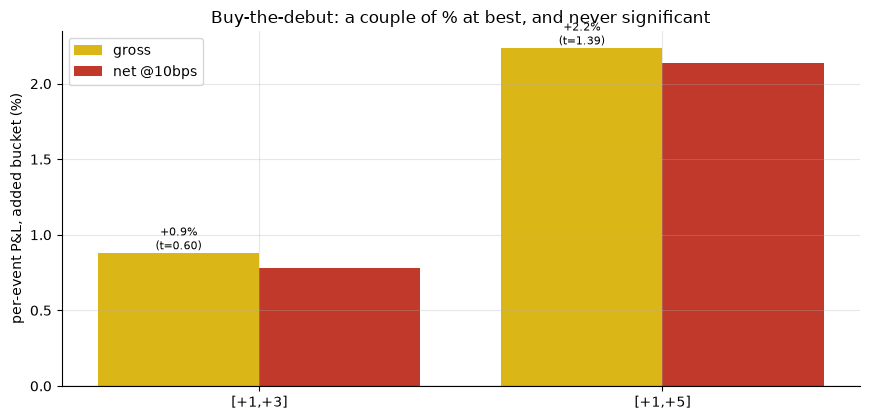

windows: [('[+1,+3]', 0.88, 't=0.6'), ('[+1,+5]', 2.23, 't=1.39')]


In [5]:
rows = R['tradable']
if HAVE_REAL:
    rows=[]
    for w,lab in [((0,2),'[+1,+3]'),((0,4),'[+1,+5]')]:
        pl=st.car_panel(PRICES, EVENTS, window=w, lag=1)
        a=st.summarize_bucket(pl.loc[pl['added'],'car'].to_numpy())
        dl=st.welch_t(pl.loc[pl['added'],'car'].to_numpy(), pl.loc[~pl['added'],'car'].to_numpy())
        nc=st.net_of_costs(a['mean_pct']/100)
        rows.append((lab, a['mean_pct'], a['t'], dl, nc['net_pct']))
labs=[r[0] for r in rows]; gross=[r[1] for r in rows]; net=[r[4] for r in rows]; tt=[r[2] for r in rows]
xx=np.arange(len(labs))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(xx-.2, gross, .4, color=AMBER, label='gross'); ax.bar(xx+.2, net, .4, color=RED, label='net @10bps')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(xx); ax.set_xticklabels(labs)
ax.set_ylabel('per-event P&L, added bucket (%)')
ax.set_title('Buy-the-debut: a couple of % at best, and never significant')
for i,(g,t) in enumerate(zip(gross,tt)): ax.annotate(f'{g:+.1f}%\n(t={t:.2f})',(i-.2,g),ha='center',va='bottom',fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()
print('windows:', [(r[0], round(r[1],2), 't='+str(round(r[2],2))) for r in rows])

Stretch the hold long enough and you can coax the debut bucket up to **+2.2%** — but at **t = 1.39** it's not significant, the added−dropped gap is a **+0.20** *t* (pure noise), and you had to hunt across windows to find even that. There's no machine here — just a prestigious list that the market, quite reasonably, already knew everything about.

## 7 · Going further 🚪

- **The effect that's actually real.** [Study 249 — Index-Inclusion](../249-index-inclusion/) runs the *S&P 500* version — the one with a forced-buying mechanism behind it. Compare the two and the whole lesson pops out: **mechanism, not prestige.**
- **The label trap.** [Study 389 — Name-Change-Effect](../389-name-change-effect/) asks whether a themed *rename* pops a stock — same attention story, same coin-flip answer.
- **Add the corpses.** Our exit tape drops the bankruptcies (J.C. Penney, Bed Bath & Beyond); rebuild them from a survivorship-free feed and the *drop* leg might finally show a penalty — but that penalty is a bankruptcy, not a tradable 'fall off the list.'

*Think making the Fortune 500 is a real catalyst? Capture the reveal-window returns, draw the same number of random dates, and show the debut pop landing **outside** the cloud — then we'll talk.*